# 05. Predictor Feature Engineering: Population Density (Eurostat)

Builds the population density predictor feature for each of the 1353 hexagons using Eurostat's 1km population grid (2021 census figures).

**Output:** grid with new `population_density_per_km2` column, saved to
`data/processed/berlin_h3_res8_with_all_features.geojson`.

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
from shapely import wkt
from shapely.geometry import Polygon

In [2]:
RAW_POP = Path("../data/raw/grid_1km.csv")

de_chunks = []
for chunk in pd.read_csv(RAW_POP, chunksize=500_000):
    de_chunk = chunk[chunk["CNTR_ID"].str.contains("DE", na=False)]
    de_chunks.append(de_chunk)

pop_de = pd.concat(de_chunks, ignore_index=True)
print(f"Germany cells: {len(pop_de)}")
pop_de.head()

Germany cells: 370276


,DIST_BORD,TOT_P_2018,TOT_P_2006,GRD_ID,TOT_P_2011,TOT_P_2021,Y_LLC,CNTR_ID,NUTS2016_3,NUTS2016_2,...,X_LLC,NUTS2021_3,NUTS2021_2,DIST_COAST,NUTS2021_1,NUTS2021_0,NUTS2024_3,NUTS2024_2,NUTS2024_1,NUTS2024_0
0,1728.22,0.0,0.0,CRS3035RES1000mN2682000E4333000,0.0,0.0,2682000,DE-AT,AT341,AT34,...,4333000,AT341,AT34,255847.60,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE
1,1574.97,105.0,118.0,CRS3035RES1000mN2682000E4334000,117.0,101.0,2682000,DE-AT,AT341,AT34,...,4334000,AT341,AT34,255200.21,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE
2,1845.67,13.0,23.0,CRS3035RES1000mN2682000E4335000,18.0,20.0,2682000,DE-AT,AT331-AT341,AT33-AT34,...,4335000,AT331-AT341,AT33-AT34,254555.11,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE
3,2063.79,0.0,0.0,CRS3035RES1000mN2682000E4336000,0.0,0.0,2682000,DE-AT,AT331-AT341,AT33-AT34,...,4336000,AT331-AT341,AT33-AT34,253912.30,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE
4,1959.08,0.0,0.0,CRS3035RES1000mN2682000E4337000,0.0,0.0,2682000,DE-AT,AT331-AT341,AT33-AT34,...,4337000,AT331-AT341,AT33-AT34,253271.82,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE


## Turning the grid coordinates into actual shapes

The csv only gives us the bottom-left corner of each 1km cell (X_LLC, Y_LLC), not a shape we can plot or overlay. since the cells are exactly 1km squares, build the square  with shapely.box() - bottom left corner + 1000m on each side.

this is done in EPSG:3035, which is the projection eurostat's coordinates are already in (a standard equal-area projection used for european statistics).

In [3]:
from shapely.geometry import box

RES = 1000  # grid resolution in meters

pop_de["geometry"] = [box(x, y, x + RES, y + RES) for x, y in zip(pop_de["X_LLC"], pop_de["Y_LLC"])]
pop_gdf = gpd.GeoDataFrame(pop_de, geometry="geometry", crs="EPSG:3035")

print(pop_gdf.crs)
pop_gdf.head()

EPSG:3035


,DIST_BORD,TOT_P_2018,TOT_P_2006,GRD_ID,TOT_P_2011,TOT_P_2021,Y_LLC,CNTR_ID,NUTS2016_3,NUTS2016_2,...,NUTS2021_3,NUTS2021_2,DIST_COAST,NUTS2021_1,NUTS2021_0,NUTS2024_3,NUTS2024_2,NUTS2024_1,NUTS2024_0,geometry
0,1728.22,0.0,0.0,CRS3035RES1000mN2682000E4333000,0.0,0.0,2682000,DE-AT,AT341,AT34,...,AT341,AT34,255847.60,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE,"POLYGON ((4334000 2682000, 4334000 2683000, 43..."
1,1574.97,105.0,118.0,CRS3035RES1000mN2682000E4334000,117.0,101.0,2682000,DE-AT,AT341,AT34,...,AT341,AT34,255200.21,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE,"POLYGON ((4335000 2682000, 4335000 2683000, 43..."
2,1845.67,13.0,23.0,CRS3035RES1000mN2682000E4335000,18.0,20.0,2682000,DE-AT,AT331-AT341,AT33-AT34,...,AT331-AT341,AT33-AT34,254555.11,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE,"POLYGON ((4336000 2682000, 4336000 2683000, 43..."
3,2063.79,0.0,0.0,CRS3035RES1000mN2682000E4336000,0.0,0.0,2682000,DE-AT,AT331-AT341,AT33-AT34,...,AT331-AT341,AT33-AT34,253912.30,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE,"POLYGON ((4337000 2682000, 4337000 2683000, 43..."
4,1959.08,0.0,0.0,CRS3035RES1000mN2682000E4337000,0.0,0.0,2682000,DE-AT,AT331-AT341,AT33-AT34,...,AT331-AT341,AT33-AT34,253271.82,AT3,AT,AT331-AT341-DE27E,AT33-AT34-DE27,AT3-DE2,AT-DE,"POLYGON ((4338000 2682000, 4338000 2683000, 43..."



the boundary file is in EPSG:4326 (lat/lon, same as the hexagons), so it needs to be reprojected to EPSG:3035 to match the population grid. 

using .intersects()  instead of a centroid check like the hexagon grid used - a lot of population squares only partially overlap Berlin along the edge, and the overlay step coming up needs those partial squares to correctly split population between Berlin and whatever's just outside it. if we dropped them now the way the out-of-boundary cafes got dropped in notebook 03, we'd lose real population right where the border cuts through a square.

Population cells overlapping Berlin: 1015


<Axes: >

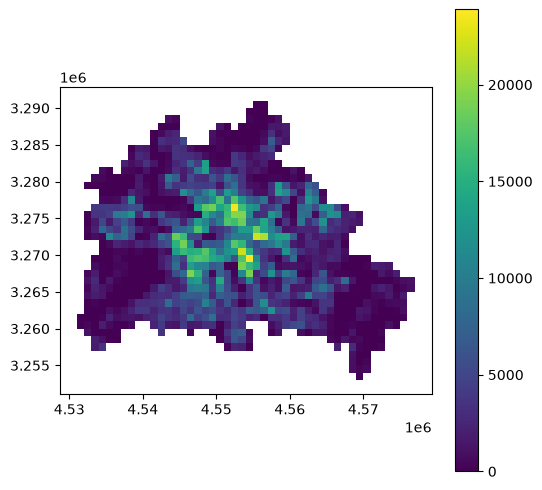

In [4]:
BOUNDARY_CSV = Path("../data/external/berlin_boundary.csv")
boundary_df = pd.read_csv(BOUNDARY_CSV)
berlin_boundary_4326 = wkt.loads(boundary_df["location"].iloc[0])

boundary_gs = gpd.GeoSeries([berlin_boundary_4326], crs="EPSG:4326")
berlin_boundary_3035 = boundary_gs.to_crs("EPSG:3035").iloc[0]

pop_berlin = pop_de.copy()
pop_berlin = gpd.GeoDataFrame(pop_berlin, geometry="geometry", crs="EPSG:3035")
pop_berlin = pop_berlin[pop_berlin.intersects(berlin_boundary_3035)].copy()

print(f"Population cells overlapping Berlin: {len(pop_berlin)}")
pop_berlin.plot(column="TOT_P_2021", legend=True, figsize=(6,6))

the hexagons were built in EPSG:4326 back in notebook 01. before they can be overlaid with the population squares they need to be in the same CRS as the population data, so reproject to EPSG:3035.

In [5]:
HEX_GRID = Path("../data/processed/berlin_h3_res8_with_osm_features.geojson")
hex_grid = gpd.read_file(HEX_GRID)

hex_grid_3035 = hex_grid.to_crs("EPSG:3035")

print(hex_grid_3035.crs)
hex_grid_3035.head(2)

EPSG:3035


,h3_index,resolution,popular_cafe_count,transit_stops_500m,rail_stations_800m,shops_500m,offices_500m,food_500m,universities_800m,coworking_500m,green_spaces_800m,culture_700m,geometry
0,881f1886e5fffff,8,0,0,1,0,0,0,0,0,6,0,"POLYGON ((4537660.652 3263853.799, 4537532.177..."
1,881f188445fffff,8,1,6,0,7,0,1,0,0,13,1,"POLYGON ((4534255.736 3261419.475, 4534127.15 ..."


## Splitting population between overlapping hexagons

each hexagon overlaps parts of several 1km population squares and none of them line up exactly.

gpd.overlay() with how="intersection" cuts both layers wherever they cross, so we end up with a bunch of small overlap pieces with each one knowing which hexagon and which population square it came from, plus its own overlap area.

For each overlap piece, work out what fraction of the *original population square* it represents (overlap area / full square area) and multiply that fraction by the square's population. that gives the piece's share of people. summing all the pieces belonging to one hexagon gives that hexagon's total estimated population.

In [6]:
# keep only the columns we actually need before the overlay, less clutter after
pop_small = pop_berlin[["GRD_ID", "TOT_P_2021", "geometry"]].copy()
pop_small["cell_area"] = pop_small.geometry.area  # should all be 1,000,000 (1km x 1km)

hex_small = hex_grid_3035[["h3_index", "geometry"]].copy()

overlay = gpd.overlay(hex_small, pop_small, how="intersection")
overlay["overlap_area"] = overlay.geometry.area
overlay["pop_share"] = (overlay["overlap_area"] / overlay["cell_area"]) * overlay["TOT_P_2021"]

print(f"Overlap pieces: {len(overlay)}")
overlay.head()

Overlap pieces: 4887


,h3_index,GRD_ID,TOT_P_2021,cell_area,geometry,overlap_area,pop_share
0,881f1886e5fffff,CRS3035RES1000mN3263000E4537000,0.0,1000000.0,"POLYGON ((4537906.935 3263061.715, 4537532.177...",298714.486188,0.000000
1,881f1886e5fffff,CRS3035RES1000mN3263000E4538000,1183.0,1000000.0,"POLYGON ((4538538.633 3263706.998, 4538410.178...",359725.084048,425.554774
2,881f1886e5fffff,CRS3035RES1000mN3264000E4538000,0.0,1000000.0,"POLYGON ((4538163.864 3264019.948, 4538187.752...",840.844841,0.000000
3,881f188445fffff,CRS3035RES1000mN3260000E4534000,2049.0,1000000.0,"POLYGON ((4534501.822 3260627.194, 4534127.15 ...",225305.088004,461.650125
4,881f188445fffff,CRS3035RES1000mN3260000E4535000,719.0,1000000.0,"POLYGON ((4535005.09 3260793.352, 4535000 3260...",6784.318453,4.877925


In [7]:
hex_pop = overlay.groupby("h3_index")["pop_share"].sum().reset_index()
hex_pop = hex_pop.rename(columns={"pop_share": "population_est"})

print(f"Hexagons with a population estimate: {len(hex_pop)}")
print(f"Total population captured: {hex_pop['population_est'].sum():,.0f}")
hex_pop.head()

Hexagons with a population estimate: 1353
Total population captured: 3,522,709


,h3_index,population_est
0,881f188401fffff,72.810647
1,881f188409fffff,214.051901
2,881f18840bfffff,71.850639
3,881f18840dfffff,292.315647
4,881f188419fffff,677.393178


## Converting to density

all hexagons are the same size at H3 resolution 8, so population count and population density will actually rank hexagons the same way. still converting to population per km2 here since that's the standard unit for this kind of feature and it's what a reader would expect to see, rather than a raw headcount tied to one specific hexagon size.

In [8]:
hex_grid_3035["hex_area_km2"] = hex_grid_3035.geometry.area / 1_000_000  # m2 to km2

hex_pop = hex_pop.merge(hex_grid_3035[["h3_index", "hex_area_km2"]], on="h3_index")
hex_pop["population_density_per_km2"] = hex_pop["population_est"] / hex_pop["hex_area_km2"]

print(hex_pop["population_density_per_km2"].describe())
hex_pop.sort_values("population_density_per_km2", ascending=False).head()

count     1353.000000
mean      3951.157179
std       4337.857715
min          0.000000
25%        547.190645
50%       2460.434502
75%       5722.616441
max      22237.954753
Name: population_density_per_km2, dtype: float64


,h3_index,population_est,hex_area_km2,population_density_per_km2
1286,881f1d4f2dfffff,14641.752538,0.658413,22237.954753
1137,881f1d4d01fffff,14214.825532,0.659102,21566.960768
1153,881f1d4d25fffff,14192.366496,0.659374,21523.987853
294,881f18b25bfffff,12916.962915,0.659185,19595.362189
266,881f18b21bfffff,12900.010879,0.659495,19560.450034


In [9]:
final_grid = hex_grid.merge(hex_pop[["h3_index", "population_density_per_km2"]], on="h3_index", how="left")

# sanity check - every hexagon should have a value, none should be missing
print(f"Hexagons missing population density: {final_grid['population_density_per_km2'].isna().sum()}")

OUT = Path("../data/processed/berlin_h3_res8_with_all_features.geojson")
final_grid.to_file(OUT, driver="GeoJSON")
print(f"Saved {len(final_grid)} hexagons with all predictor features -> {OUT}")

Hexagons missing population density: 0
Saved 1353 hexagons with all predictor features -> ..\data\processed\berlin_h3_res8_with_all_features.geojson
